## Suivi des incendies de forêt en temps réel

In [3]:
!pip install opencv-python

### Librairies

In [4]:
# computer vision
# Analyse de la vidéo frame par frame
# le Transfer Learning (MobileNetV2)
# OpenCV : Pour lire la vidéo

import os
import cv2
from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualisations
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

from tensorflow.keras import mixed_precision
from PIL import ImageFile
import time

import warnings
warnings.filterwarnings('ignore')

### Préparation des données : (Satellite forest fire dataset)

- Ce sont des images extraites via l'API MapBox (vue du ciel du Canada).
  
- Les images JPG font environ 350x350 pixels.

- Le piège avec les satellites, c'est de confondre Feu et Nuages ou Reflets. 

- Dossier nowildfire : Des forêts vertes simples, des forêts avec des nuages (très important, sinon le modèle croira que nuage = fumée = feu), des zones désertiques ou rocheuses (qui peuvent être orangées comme le feu).

- Fumée vs Feu : Sur les images satellites, la fumée est souvent plus visible que les flammes elles-mêmes. Ton dataset doit contenir beaucoup de fumée.

- Vue aérienne/zénithale : On doit voir la canopée des arbres, pas les troncs.

- Le feu ressemble souvent à une petite tache orange ou à un gros nuage de fumée grise vue du dessus.

In [5]:
data_dir = '/kaggle/input/wildfire-prediction-dataset' 
print("Contenu du dossier principal :", os.listdir(data_dir))

Contenu du dossier principal : ['valid', 'test', 'train']


In [ ]:
print(f"🔍 Début de la vérification dans : {data_dir}")

corrupted_count = 0
valid_count = 0
for folder in os.listdir(data_dir): # On parcourt train, test, valid
    folder_path = os.path.join(data_dir, folder)

    for sub_folder in os.listdir(folder_path): # On parcourt les sous-dossiers (wildfire, nowildfire)
        sub_folder_path = os.path.join(folder_path, sub_folder)     
        print(f"   📂 Vérification du dossier : {folder}/{sub_folder}")
        
        for image in os.listdir(sub_folder_path):
            image_path = os.path.join(sub_folder_path, image)
            
            try:
                img = cv2.imread(image_path)
                if img is None:
                    raise Exception("Image vide ou illisible par OpenCV")

                load_img(image_path)
                valid_count += 1
            except Exception as e:
                corrupted_count += 1
                print(f"      ❌ Image corrompue détectée : {image_path}")
                print(f"      (Erreur : {e})")

print(f"Images valides : {valid_count}")
print(f"Images corrompues : {corrupted_count}")

if corrupted_count == 0:
    print("Le dataset est 100% propre.")
else:
    print("Attention : Il y a des images corrompues. Comme on ne peut pas supprimer dans input, le code d'entraînement risque de planter.")

In [6]:
# --- CONFIGURATION ---
TRAIN_DIR = '/kaggle/input/wildfire-prediction-dataset/train'
VALID_DIR = '/kaggle/input/wildfire-prediction-dataset/valid'
TEST_DIR  = '/kaggle/input/wildfire-prediction-dataset/test'

IMG_SIZE = (350, 350) 
BATCH_SIZE = 32

# --- GÉNÉRATEURS ---
fire_datagen = ImageDataGenerator(
    rescale=1./255,
    
    rotation_range=40,           # Augmenté de 20 à 30
    width_shift_range=0.3,       # Augmenté de 0.2 à 0.3
    height_shift_range=0.3,      # Augmenté de 0.2 à 0.3

    # Important pour les flammes/fumée
    brightness_range=[0.6, 1.4],  # Large range pour nuit/jour
    zoom_range=[0.7, 1.3],        # Distances variables
    
    shear_range=0.3,             # Ajouté
    
    horizontal_flip=True,
    vertical_flip=True,          # Ajouté
    
    # Simulation de conditions atmosphériques
    channel_shift_range=50.0,     # Changement de teinte
    fill_mode='reflect'
)

# Pour la validation et test, seulement rescale
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Chargement des images d'entraînement...")
train_generator = fire_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

print("Chargement des images de validation...")
validation_generator = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Chargement des images de test...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Classes détectées : {train_generator.class_indices}")

Chargement des images d'entraînement...
Found 30250 images belonging to 2 classes.
Chargement des images de validation...
Found 6300 images belonging to 2 classes.
Chargement des images de test...
Found 6300 images belonging to 2 classes.
Classes détectées : {'nowildfire': 0, 'wildfire': 1}


In [7]:
print(f"Classes détectées : {train_generator.class_indices.items()}")

Classes détectées : dict_items([('nowildfire', 0), ('wildfire', 1)])


### EDA

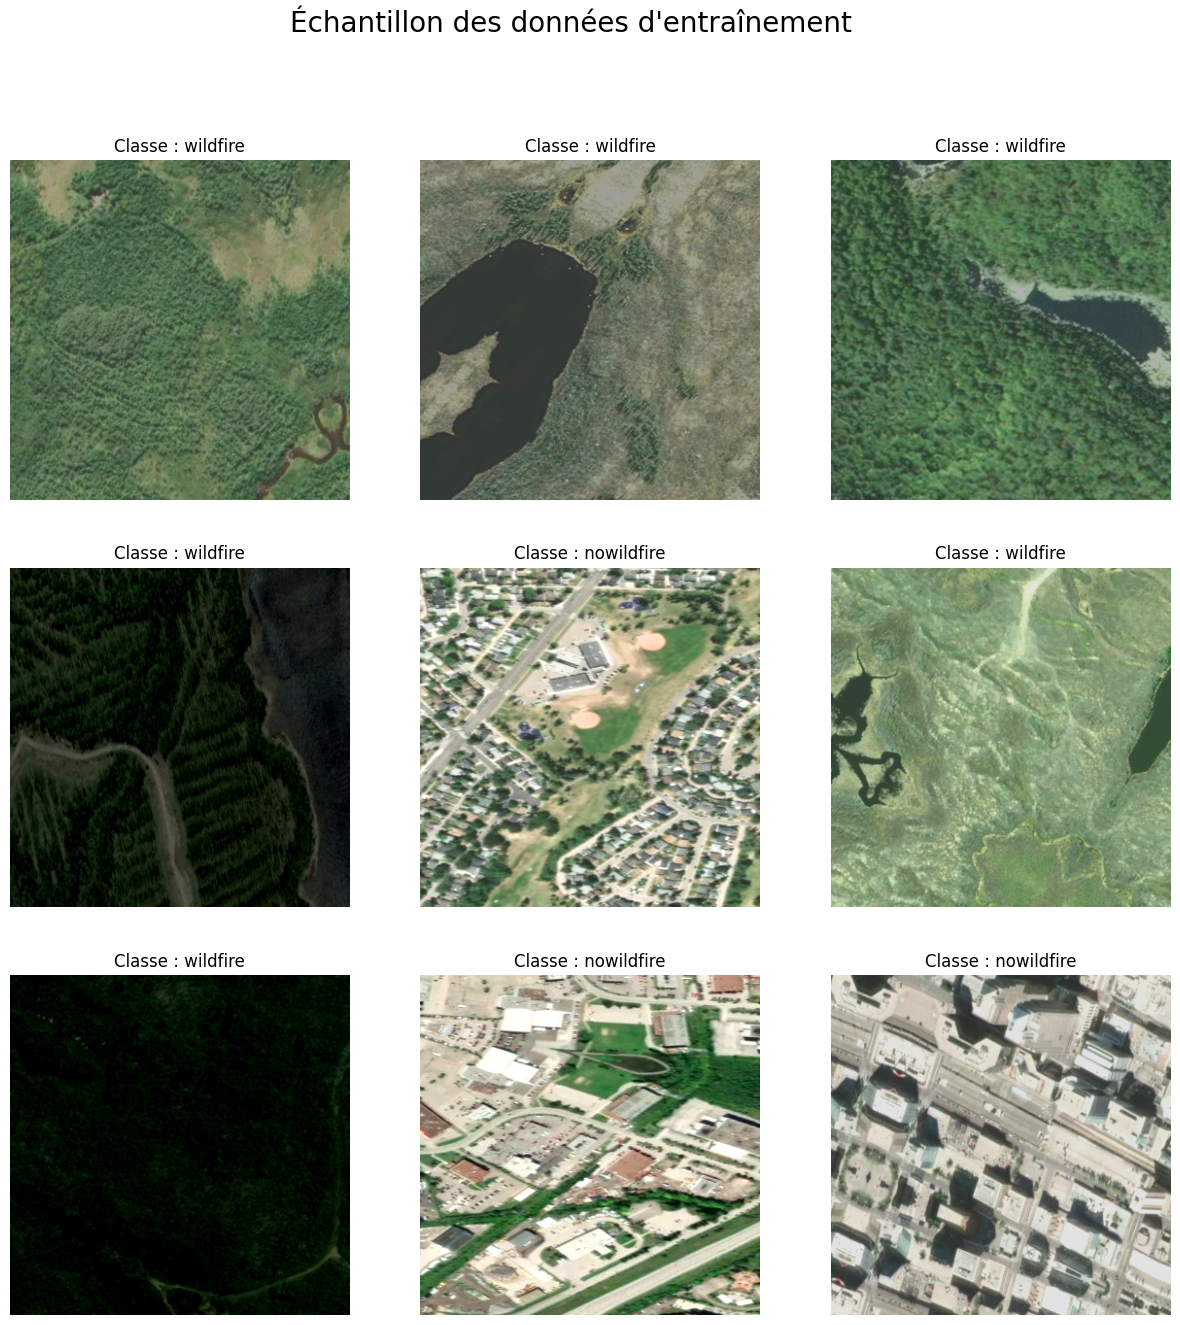

In [8]:
# --- VISUALISATION D'UN BATCH D'IMAGES ---
images, labels = next(train_generator)
class_dict = {v: k for k, v in train_generator.class_indices.items()} # {0: 'nowildfire', 1: 'wildfire'}

plt.figure(figsize=(15, 15))
for i in range(9): 
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_index = labels[i]
    plt.title(f"Classe : {class_dict[class_index]}")
    plt.axis("off")

plt.suptitle("Échantillon des données d'entraînement", fontsize=20);

In [9]:
train_generator.classes # la liste de tous les labels (0, 0, 1, 0...)

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [10]:
# --- VISUALISATION DE LA DISTRIBUTION (ÉQUILIBRE DES DONNÉES) ---
class_names = list(train_generator.class_indices.keys())
counts_train = [0] * len(class_names)

train_counts = pd.Series(train_generator.classes).value_counts().sort_index()
val_counts = pd.Series(validation_generator.classes).value_counts().sort_index()
test_counts = pd.Series(test_generator.classes).value_counts().sort_index()

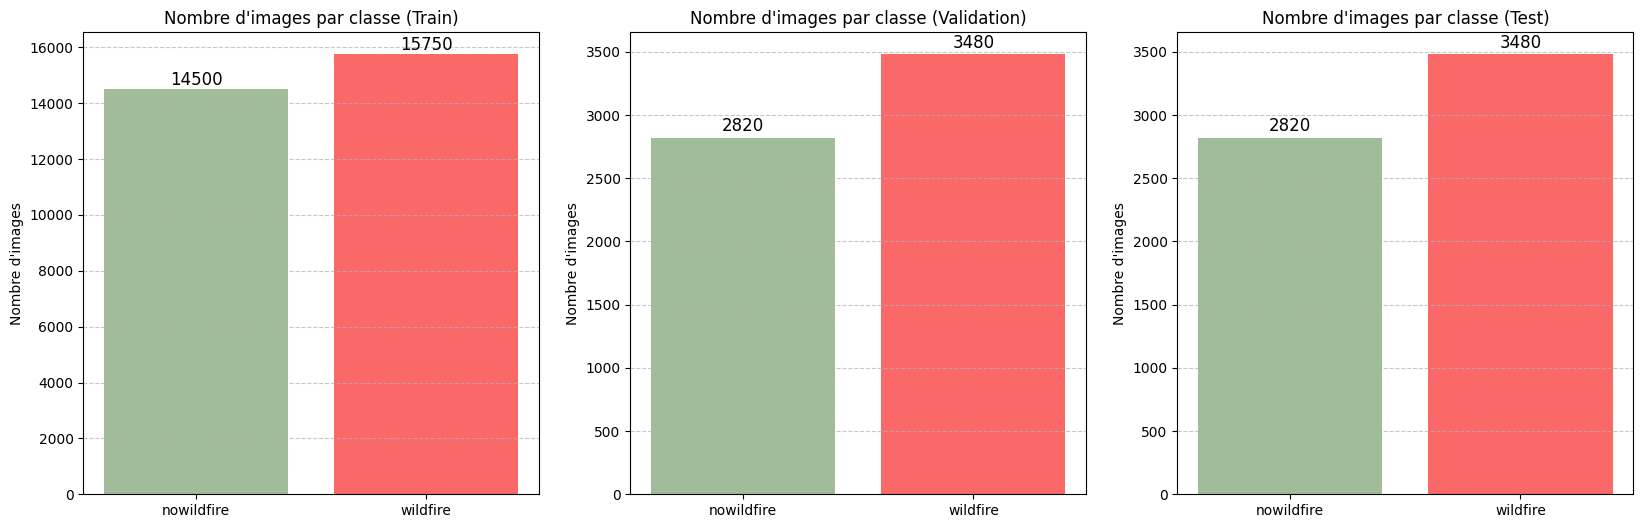

In [11]:
plt.figure(figsize=(20, 6))
counts = [train_counts, val_counts, test_counts]
splits = ["Train", "Validation", "Test"]
for idx, c in  enumerate(counts):
    plt.subplot(1, 3, idx+1)
    bars = plt.bar(class_names, c.values, color=['#A1BC98', '#FA6868'])

    for bar in bars:
        y_value = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y_value + 20, int(y_value), ha='center', va='bottom', fontsize=12)
    
    plt.title(f"Nombre d'images par classe ({splits[idx]})")
    plt.ylabel("Nombre d'images")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

**Hypothèse :** Les images de feu devraient avoir beaucoup plus de pixels Rouges. Les images "Nowild Fire" devraient avoir plus de Vert (forêt) ou de Gris/Blanc (nuages/roche).

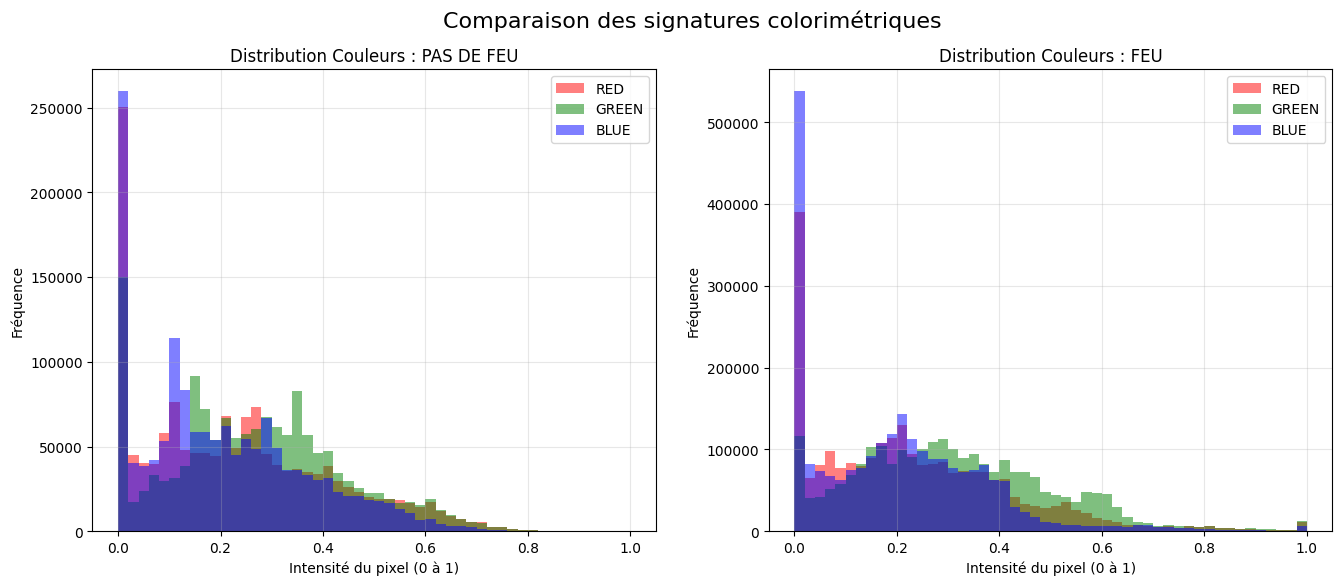

In [12]:
images, labels = next(train_generator)
no_fire_imgs = images[labels == 0]
fire_imgs = images[labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
def plot_histogram(images, title, ax):
    # Canaux R, G, B
    colors = ['red', 'green', 'blue']
    for idx, color in enumerate(colors):
        pixel_values = images[:, :, :, idx].flatten() # On aplatit toutes les valeurs de pixels de ce canal
        ax.hist(pixel_values, bins=50, color=color, alpha=0.5, label=f'{color.upper()}')
    ax.set_title(title)
    ax.set_xlabel("Intensité du pixel (0 à 1)")
    ax.set_ylabel("Fréquence")
    ax.legend()
    ax.grid(True, alpha=0.3)

plot_histogram(no_fire_imgs, "Distribution Couleurs : PAS DE FEU", axes[0])
plot_histogram(fire_imgs, "Distribution Couleurs : FEU", axes[1])
plt.suptitle("Comparaison des signatures colorimétriques", fontsize=16);

### Le Modèle (Keras) : Un classificateur binaire

- Puisque les images sont grandes (350x350), on doit construire une architecture assez profonde (plusieurs couches) pour réduire la taille de l'image progressivement tout en augmentant le nombre de "filtres" (les détecteurs de caractéristiques).

- L'architecture que je propose : Le "Pyramidal CNN (Convolutional Neural Network) ".

#### ARCHITECTURE DU MODÈLE

In [13]:
# Configuration GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Vérifie si GPU est détecté
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU configuré avec succès!")

Num GPUs Available:  1
GPU configuré avec succès!


In [14]:
# Surveiller l'utilisation GPU pendant l'entraînement
!nvidia-smi 

Sun Jan  4 19:01:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             26W /  250W |       3MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
# Conv2D (détection) et MaxPooling2D (réduction de taille).
# Filtres : On commence petit (32) et on double à chaque étape (64 -> 128)
# car plus l'image devient petite, plus l'information devient complexe.
from tensorflow.keras import regularizers, layers
model = tf.keras.Sequential([
        # Bloc 1 - Détection de contours/fumée
        layers.Conv2D(32, (5, 5), padding='same', activation='relu', 
                     input_shape=(350, 350, 3)),
        layers.BatchNormalization(),
        MaxPooling2D(2, 2), # Divise la taille de l'image par 2
        Dropout(0.1),  # Dropout tôt pour régulariser : Evite le Overfitting
        
        # Bloc 2 - Détection de textures (fumée épaisse)
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.2),
        
        # Bloc 3 - Détection de flammes (couleurs/orange)
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),
        
        # Bloc 4 - Détection de motifs complexes
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.4),
        
        # Attention aux couleurs (feu = rouge/orange)
        layers.Conv2D(32, (1, 1), activation='relu'),  # Réduction canal
        
        # Global pooling
        layers.GlobalAveragePooling2D(),
        
        # Classification
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        
        layers.Dense(1, activation='sigmoid')
    ])

I0000 00:00:1767553313.741805     485 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


#### COMPILATION

In [16]:
# mixed precision pour accélérer l'entraînement
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [17]:
optimizer = Adam(
    learning_rate=0.0001,  
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

import tensorflow as tf
from tensorflow.keras.losses import BinaryCrossentropy

import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.75):
    def focal_loss_fn(y_true, y_pred):
        # S'assurer que y_true a la même shape que y_pred
        y_true = tf.expand_dims(y_true, axis=-1) if len(y_true.shape) < len(y_pred.shape) else y_true
        
        # Éviter les valeurs extrêmes pour la stabilité numérique
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        
        # Calcul du focal loss
        cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        modulating_factor = K.pow(1 - p_t, gamma)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        
        return K.mean(alpha_factor * modulating_factor * cross_entropy, axis=-1)
    
    return focal_loss_fn

# Utilisation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.75),  # alpha=0.75 pour pénaliser plus les faux négatifs
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 350, 350, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 350, 350, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 175, 175, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 175, 175, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 173, 173, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 173, 173, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 86, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 86, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 84, 84, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 84, 84, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 413,153 (1.58 MB)

 Trainable params: 411,937 (1.57 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard

# Early stopping basé sur le F1-Score
class F1EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=7, min_delta=0.001):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.best_f1 = 0
        self.wait = 0
        
    def on_epoch_end(self, epoch, logs=None):
        val_precision = logs.get('val_precision')
        val_recall = logs.get('val_recall')
        
        if val_precision and val_recall:
            val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)
            
            if val_f1 > self.best_f1 + self.min_delta:
                self.best_f1 = val_f1
                self.wait = 0
                print(f"✓ F1 amélioré à: {val_f1:.4f}")
            else:
                self.wait += 1
                if self.wait >= self.patience:
                    print(f"Arrêt précoce déclenché. Meilleur F1: {self.best_f1:.4f}")
                    self.model.stop_training = True

In [19]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Réduit le LR par 2
    patience=3,           # Attendre 3 epochs sans amélioration
    min_lr=1e-7,          # LR minimum
    verbose=1
)

# Arrête si la "val_loss" ne descend plus depuis 10 époques
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # Augmenté de 5 à 10
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'wildfire_detection_model.keras', 
    monitor='val_auc', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

callbacks = [
    early_stop,
    checkpoint,
    reduce_lr,
    F1EarlyStopping(patience=7),
    
    # TensorBoard pour visualisation
    TensorBoard(
        log_dir='./logs',
        histogram_freq=1,
        write_graph=True,
        write_images=True
    )
]

On ajoute deux sécurités (Callbacks) :

- EarlyStopping : Arrête l'entraînement si le modèle ne s'améliore plus (évite de perdre du temps).

- ModelCheckpoint : Sauvegarde la meilleure version du modèle, pas la dernière (qui est souvent surentraînée).

### Entraînement

In [20]:
# autorise le chargement des images tronquées/corrompues
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [21]:
from sklearn.utils import class_weight

# les poids des classes
train_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Poids des classes: {class_weights_dict}")

Poids des classes: {0: np.float64(1.043103448275862), 1: np.float64(0.9603174603174603)}


In [ ]:
print("Début de l'entraînement...")

# On lance le chronomètre
start_time = time.time()

history = model.fit(
    train_generator,
    class_weight=class_weights_dict,  
    steps_per_epoch=train_generator.samples // BATCH_SIZE,  # Combien de batchs par Epoch
    epochs=100,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# On arrête le chronomètre
end_time = time.time()

# Calcul de la durée
duree_totale = end_time - start_time
minutes = int(duree_totale // 60)
secondes = int(duree_totale % 60)

print("✅ Entraînement terminé !")
print(f"⏱️ Temps total d'entraînement : {minutes} min {secondes} sec")

Début de l'entraînement...
Epoch 1/100


I0000 00:00:1767553337.323822     559 service.cc:152] XLA service 0x7a4f3c002a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767553337.323866     559 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767553338.123007     559 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1767553349.621156     559 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


371/945 ━━━━━━━━━━━━━━━━━━━━ 9:32 997ms/step - accuracy: 0.7470 - loss: 0.1404

### Evaluation

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Courbe de Précision 
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Précision (Accuracy)')
    plt.legend()

    # Courbe de Perte 
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Perte (Loss)')
    plt.legend()
    plt.show()
plot_history(history)

### Détection du feu en direct dans une vidéo satellite

In [ ]:
# Bird's-eye view based
# --- CONFIGURATION ---
MODEL_PATH = 'wildfire_detection.h5' 
VIDEO_PATH = '/kaggle/input/wildfire-video/wildfire_video.mp4'
OUTPUT_PATH = 'output_satellite.mp4'
CONFIDENCE_THRESHOLD = 0.6 

print("Chargement du modèle...")
model = load_model(MODEL_PATH)

# Initialisation de la lecture et de l'écriture
cap = cv2.VideoCapture(VIDEO_PATH)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

# Codec pour sauvegarder en MP4 sur Kaggle
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

print("Traitement de la vidéo en cours... (Patientez)")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # --- PRÉTRAITEMENT ---
    resized_frame = cv2.resize(frame, (350, 350))
    img_array = tf.keras.preprocessing.image.img_to_array(resized_frame)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # --- PRÉDICTION ---
    prediction = model.predict(img_array, verbose=0)
    probability = prediction[0][0]
    
    label = "Normal"
    color = (0, 255, 0) # Vert
    if probability > CONFIDENCE_THRESHOLD: 
        label = f"ALERTE FEU ({probability*100:.1f}%)"
        color = (0, 0, 255) # Rouge
    
    # --- DESSIN ---
    cv2.putText(frame, label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    if "ALERTE" in label:
        cv2.rectangle(frame, (0,0), (width, height), color, 20)

    # --- SAUVEGARDE ---
    out.write(frame)
cap.release()
out.release()
print(f"✅ Terminé ! Vidéo sauvegardée sous : {OUTPUT_PATH}")

Perspectives :

- Transfer Learning : Utilisation de MobileNetV2 pour réduire le temps d'entraînement et garantir une inférence rapide (fps élevé).

- Data Augmentation : ImageDataGenerator permet au modèle de généraliser mieux et de ne pas apprendre par cœur les images de feu.

- Pipeline Temps Réel : Intégration fluide entre OpenCV (capture de flux) et TensorFlow (traitement tensoriel).

- La segmentation (colorier exactement la zone de feu en rouge sur la vidéo) au lieu de la simple classification (visuellement plus impressionnant)

- Dataset "Landsat" ou "Sentinel-2" (Filtres Feux) : C'est plus complexe à manipuler (souvent des fichiers .tiff multispectraux), mais c'est la réalité du métier.